# LCM Training Monitor

This notebook provides tools to monitor the training progress of the LCM model and perform inference.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

## Training Metrics Visualization

In [2]:
def load_metrics(csv_path: str) -> pd.DataFrame:
    """Load training metrics from CSV file."""
    metrics_df = pd.read_csv(csv_path)
    metrics_df["lr-AdamW"] = metrics_df["lr-AdamW"].ffill()

    metrics_df = metrics_df[metrics_df["train_loss"].notna() + metrics_df["val_loss"].notna()]
    metrics_df = metrics_df.groupby("epoch").mean()

    metrics_df = metrics_df.reset_index()

    return metrics_df

In [3]:
def plot_metrics(metrics_df: pd.DataFrame) -> None:
    """Plot training metrics."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(metrics_df["epoch"], metrics_df["train_loss"], label="Train Loss")
    ax1.plot(metrics_df["epoch"], metrics_df["val_loss"], label="Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_ylim(0.00, 0.8)
    ax1.set_title("Training and Validation Loss")
    ax1.legend()
    ax1.grid(True)

    # Plot learning rate
    ax2.plot(metrics_df["epoch"], metrics_df["lr-AdamW"], label="Learning Rate")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning Rate")
    ax2.set_title("Learning Rate Schedule")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

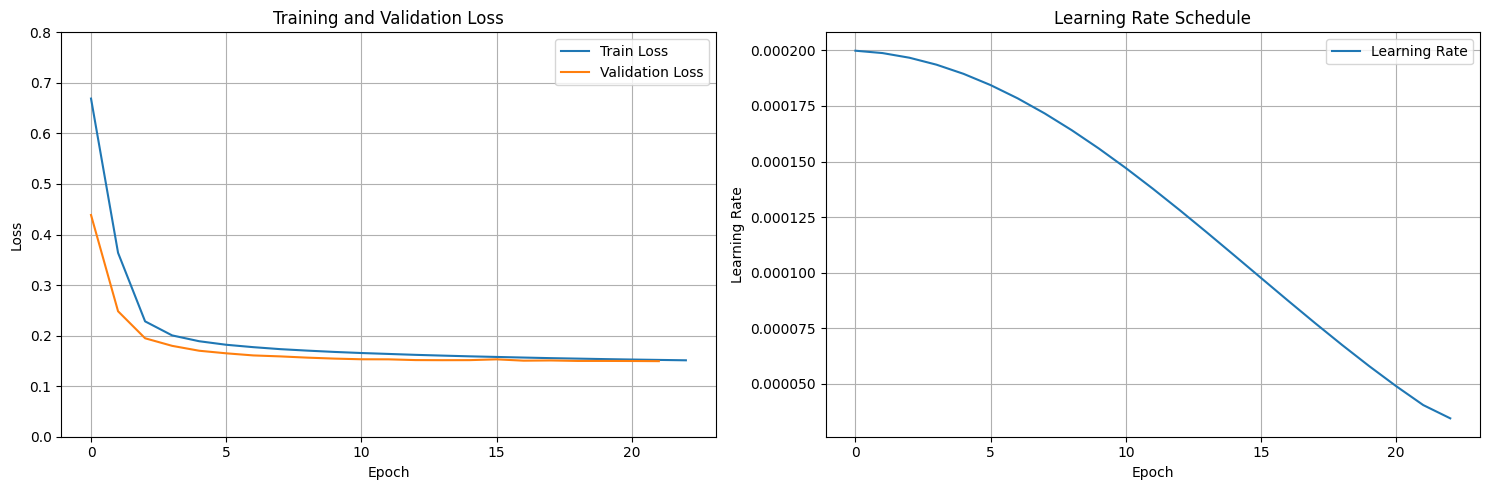

In [16]:
metrics_path = "/home/yannhallouard/PycharmProjects/large_concept_model/lightning_logs/version_17/metrics.csv"
metrics_df = load_metrics(metrics_path)

plot_metrics(metrics_df)

## Model Inference

This section allows you to load a trained model and perform inference on new text.

In [9]:
from lcm_explo.adapters.embedding_repository.file_system import FileSystemEmbeddingRepository
from lcm_explo.domain.models.base_lcm import BaseLCM, BaseLCMConfig
from lcm_explo.domain.usecases.train import BaseLCMTrainingModule

In [10]:
embeddings_repo = FileSystemEmbeddingRepository(base_path="data")
example_doc = embeddings_repo.load_document_embeddings("logicot_entry_0")
example_doc.embeddings.shape

torch.Size([43, 1024])

In [85]:
def generate_next_concepts(model: BaseLCM, input_embeddings: torch.Tensor, num_steps: int = 10) -> torch.Tensor:
    """Generate next concepts using the model."""
    device = next(model.parameters()).device

    # Move input to same device as model
    input_embeddings = input_embeddings.to(device)

    # Generate next concepts
    with torch.no_grad():
        current_sequence = input_embeddings
        generated_sequence = [current_sequence]

        for _ in range(num_steps):
            # Get next concept prediction
            padding_mask = torch.ones(current_sequence.shape[0]).to(device)
            next_concept = model(current_sequence, padding_mask)

            # Update sequence
            current_sequence = torch.cat([current_sequence[:, 1:], next_concept[:, -1:]], dim=1)
            generated_sequence.append(next_concept[:, -1:])

    return torch.cat(generated_sequence, dim=1)

In [17]:
checkpoint_path = "data/checkpoints/lcm-epoch=22-val_loss=0.1494.ckpt"
config = BaseLCMConfig(
    max_seq_len=32
)
model = BaseLCMTrainingModule.load_from_checkpoint(
    checkpoint_path,
)

In [20]:
from transformers import NllbTokenizer

from lcm_explo.m2m_100 import M2M100DecoderModel

decoder = M2M100DecoderModel.from_pretrained("cointegrated/SONAR_200_text_decoder_hf").to("cuda")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

In [100]:
# Load some example embeddings
embeddings_repo = FileSystemEmbeddingRepository(base_path="data")
example_doc = embeddings_repo.load_document_embeddings("...Baby One More Time (album)")

# Generate next concepts
input_embeddings_part = example_doc.embeddings[-32:].unsqueeze(0)  # Add batch dimension
input_padding = torch.zeros(
    (32 - input_embeddings_part.shape[1], input_embeddings_part.shape[2]), device=input_embeddings_part.device
)
input_embeddings = torch.cat([input_embeddings_part, input_padding.unsqueeze(0)], dim=1)
padding_mask = torch.cat([torch.ones((1, input_embeddings_part.shape[1])), torch.zeros((1, input_padding.shape[0]))], dim=1)
generated_sequence = generate_next_concepts(model, input_embeddings, num_steps=3)

print(f"Generated sequence shape: {generated_sequence.shape}")

Generated sequence shape: torch.Size([1, 35, 1024])


In [101]:
padding_mask.shape

torch.Size([1, 32])

In [102]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

all_text = []

for i in range(generated_sequence.shape[1]):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=generated_sequence[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    all_text.append(text_out[0])
    print(text_out[0])
    
#print(all_text)

RCA Records signed Aguilera and rushed her debut single to capitalize on Spears
Aguilera's album sold millions but not as many as ...Baby One More Time
Simpson consciously modeled her personality as more mature than Spears; her single "I
Moore's first single, "Candy", hit the airwaves a month before Simpson
Fueling media stories about their competition for the first place, Spears and Aguilera trad
The Daily Yomiuri reported that "critics have hailed her as the most talented
"Britney Spears carries the classic archetype of the rock & roll teen queen
Rami Yacoub who co-produced Spears' debut album with lyricist Max
"I know from Denniz Pop and Max's previous productions, when we do songs
With N' Sync and the Backstreet Boys, we had to push for that mid
When Britney did that, she got that kind of raspy, sexy voice".
Chuck Taylor of Billboard noted, "Spears has become a consummate performer, with swi
"....You Drive Me" Crazy", her third single.. demonstrates Spears' own development
Stephen 

In [25]:
all_text[-11]

'int2: the earth rotating around the sun causes leo to appear in different areas in the sky'

In [15]:
from transformers import NllbTokenizer
from wtpsplit import SaT

from lcm_explo.domain.usecases.encode import encode_text_sonar
from lcm_explo.m2m_100 import M2M100EncoderModel

sonar_encoder = M2M100EncoderModel.from_pretrained("cointegrated/SONAR_200_text_encoder_hf").to("cuda")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

splitter = SaT("sat-3l")

In [31]:
my_text = """
Its position appears to shift relative to the horizon.
Based on the context, we can infer the hypothesis: the earth rotating on its axis causes stars to move relative to the horizon during the night
Reasoning chain: sent11 & sent3 & sent8 -> int1: apparent motion of stars is when stars appear to move relative to earth's position; int1 & sent6 -> int2: the earth rotating on its axis causes apparent motion of stars; int2 & sent23 -> hypothesis;
Proof: [BECAUSE] a star is a kind of celestial object / celestial body [AND] apparent motion is when an object appears to move relative to another object 's position [AND] earth is a kind of celestial object [INFER] int1: apparent motion of stars is when stars appear to move relative to earth's position [BECAUSE] int1 [AND] the earth rotating on its axis causes stars to appear to move across the sky at night [INFER] int2: the earth rotating on its axis causes apparent motion of stars [BECAUSE] int2 [AND] stars appear to move relative to the horizon during the night [INFER] int3: the earth rotating on its axis causes stars to move relative to the horizon during the night
""" 

embeddings = encode_text_sonar(
    my_text, device="cuda", sonar_tokenizer=sonar_tokenizer, sonar_model=sonar_encoder, splitter=splitter
)

input_embeddings = embeddings.unsqueeze(0)
my_generated_sequence = generate_next_concepts(model, input_embeddings, num_steps=10)

print(f"Generated sequence shape: {my_generated_sequence.shape}")

NameError: name 'model' is not defined

In [32]:
from transformers.modeling_outputs import BaseModelOutput

def split_long_text(tokenizer, splitter, text: str, max_length: int = 1024) -> list[str]:
    splits = splitter.split(text)
    splits = [split for split in splits if split.replace(" ", "") != "" and len(split) > 10]
    return splits


refined_text = my_text.replace("sent", ". sent")


embeddings = []
with torch.no_grad():
    chunks = split_long_text(sonar_tokenizer, splitter, refined_text)
    for chunk in chunks:
        inputs = sonar_tokenizer(chunk, return_tensors="pt", padding=True, truncation=True)
        inputs = {k: v.to("cuda") for k, v in inputs.items()}
        outputs = sonar_encoder(**inputs)
        embeddings.append(outputs.last_hidden_state.mean(dim=1))

out = torch.vstack(embeddings)

generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=out.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
text_out

['Its position seems to shift relative to the horizon.',
 'Based on the context, we can infer the hypothesis: that earth rotating on',
 'Reasoning chain:',
 'sent11 & .',
 'int1: apparent movement of stars is when stars appear to move relative to earth position;',
 'int2: the earth rotating on its axis causes apparent movement of stars;',
 'sent23 -> hypothesis;',
 'Proof: [Why]',
 'a star is a kind of celestial object / celestial body [AND]',
 'apparent motion is when an object appears to move relative to the position of another object [AND',
 'earth is a kind of celestial object [INFER]',
 "int1: apparent movement of stars is when stars appear to move relative to earth's position",
 'int1 [AND]',
 "the earth's rotation on its axis causes stars to appear to move across the night",
 'int2: Earth rotating on its axis causes apparent movement of stars [WHY]',
 'int2 [AND]',
 'Stars seem to move relative to the horizon during the night [INFER].',
 'int3: the earth rotating on its axis cau

In [33]:
chunks

['Its position appears to shift relative to the horizon.',
 'Based on the context, we can infer the hypothesis: the earth rotating on its axis causes stars to move relative to the horizon during the night',
 'Reasoning chain: ',
 'sent11 & . ',
 "int1: apparent motion of stars is when stars appear to move relative to earth's position; ",
 'int2: the earth rotating on its axis causes apparent motion of stars; ',
 'sent23 -> hypothesis;',
 'Proof: [BECAUSE] ',
 'a star is a kind of celestial object / celestial body [AND] ',
 "apparent motion is when an object appears to move relative to another object 's position [AND] ",
 'earth is a kind of celestial object [INFER] ',
 "int1: apparent motion of stars is when stars appear to move relative to earth's position [BECAUSE] ",
 'int1 [AND] ',
 'the earth rotating on its axis causes stars to appear to move across the sky at night [INFER] ',
 'int2: the earth rotating on its axis causes apparent motion of stars [BECAUSE] ',
 'int2 [AND] ',
 'st

In [30]:
from tqdm import tqdm
from transformers.modeling_outputs import BaseModelOutput

my_all_text = []

for i in tqdm(range(my_generated_sequence.shape[1])):
    # Decoding into the original (English) language
    generator_out = decoder.generate(
        # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
        # encoder_outputs=enc_out,
        encoder_outputs=BaseModelOutput(last_hidden_state=my_generated_sequence[:, i, :].unsqueeze(1)),
        num_beams=5,
        forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
    )
    text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
    my_all_text.append(text_out[0])
print(my_all_text)

NameError: name 'my_generated_sequence' is not defined